# Imports

In [1]:
from lineagetree import read_from_mastodon
import numpy as np
import matplotlib.pyplot as plt
import h5py

# CUSTOM FUNCTIONS
import watermasks.utils as utils
import watermasks.main as main

import importlib # to reload functions for testing in notebooks

# Load Data

In [ ]:
# --- LOAD DIRECTORIES FOR DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = utils.paths('JR_22-10-18')

VIEW='0' # Choose dataset view

# IMPORT REG. MATRICES AND LINEAGETREE
R_of_t = utils.import_registration_mats_multiview(path_xml, 0, 500)
lT = read_from_mastodon(path_mast)

TP = 500 # Choose timepoint

# IMPORT INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    raw_image = f5[f't00{TP}'][f's0{VIEW}']['2']['cells'][:]

# Preparatory Steps

In [3]:
# CALCULATE SCALING FACTORS
shape_full_h5 = np.array([300, 1888, 2100]) # for no downscaling (0-th level of the hdf5), (as measured in T7_3 data (dir = H:))
shape_raw_image = np.array(np.shape(raw_image))
scaling = shape_raw_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_raw_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS AT CURRENT TIMEPOIN
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

# PREPROCCESS IMAGE TO CREATE WATERSHED INPUT
im_for_ws = main.preprocess_im(raw_image)

full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]


# Adaptive Watershed

In [4]:
ws, all_seeds, missed_seeds, stat_table = main.ws_adaptive_mask(im_for_ws, seeds_array, min_int=np.percentile(im_for_ws.ravel(), 80), max_int=np.percentile(im_for_ws.ravel(), 99.9), 
                                                                percentage_list=[100, 99.99, 99.9, 99, 97, 95, 90, 80, 70])

Processing thresholds for watershed:: 100%|██████████| 9/9 [01:33<00:00, 10.42s/step]


In [5]:
utils.display_ws_thresholding_results(stat_table, all_seeds)

+------------+------------------+-------------+--------------+
| Percentage | Percentile Value | Found Seeds | Missed Seeds |
+------------+------------------+-------------+--------------+
|   100 %    |      166.0       |     44      |     758      |
+------------+------------------+-------------+--------------+
|  99.99 %   |      164.0       |      1      |     757      |
+------------+------------------+-------------+--------------+
|   99.9 %   |      155.0       |      8      |     749      |
+------------+------------------+-------------+--------------+
|    99 %    |      111.0       |     69      |     680      |
+------------+------------------+-------------+--------------+
|    97 %    |       83.0       |     108     |     572      |
+------------+------------------+-------------+--------------+
|    95 %    |       70.0       |     93      |     479      |
+------------+------------------+-------------+--------------+
|    90 %    |       52.0       |     152     |     327

# Segmentation Correction

In [6]:
# ws = main.add_lost_seeds(ws, seeds_array, missed_seeds)

# Visualization / Eperimentation

In [9]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_image(seeds_array, colormap='#aaff00ff')
viewer.add_labels(ws)
napari.run()

What is the multiples problem:

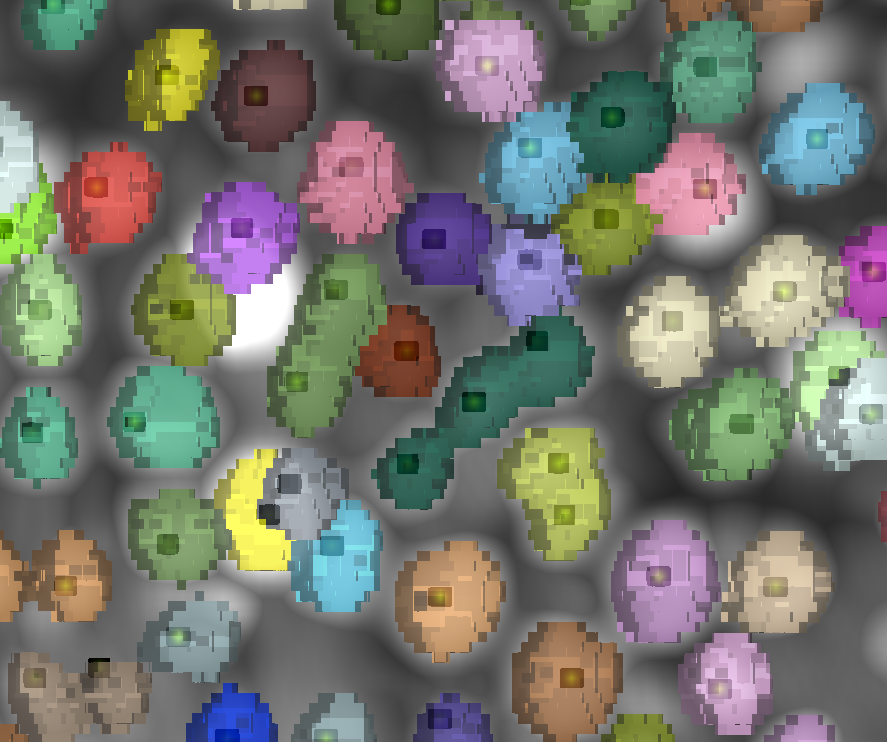

You have many annotations in the same region.

## Explore region 501

The dark green region has the label 501 in the watershed and engulfs the seeds 97, 501, 220

In [7]:
np.transpose(np.where(seeds_array==97)) in np.transpose(np.where(ws==501))

True

In [9]:
seeds_pos ={}

In [ ]:
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

In [11]:
seeds_pos[220]

array([205, 269,  61], dtype=uint16)

In [12]:
ws[tuple(seeds_pos[220].T)] = 220

In [13]:
ws[tuple(seeds_pos[97].T)] = 97

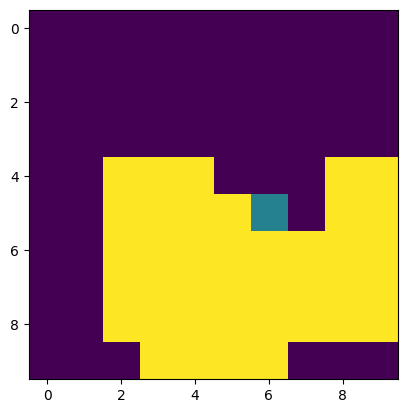

In [19]:
plt.imshow(ws[200:210, 269, 55:65])

In [168]:
viewer = napari.Viewer()
viewer.add_image(im_for_ws[200:230, 250:275, 55:65])
# viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_image(seeds_array[200:230, 250:275, 55:65])
viewer.add_labels(ws[200:230, 250:275, 55:65])
napari.run()

In reality, the seeds that look like they are inside the undersegmented regions, ARE NOT INCLUDED IN THE REGIONS (label = 97 is viewed in pink, outside of region 501)

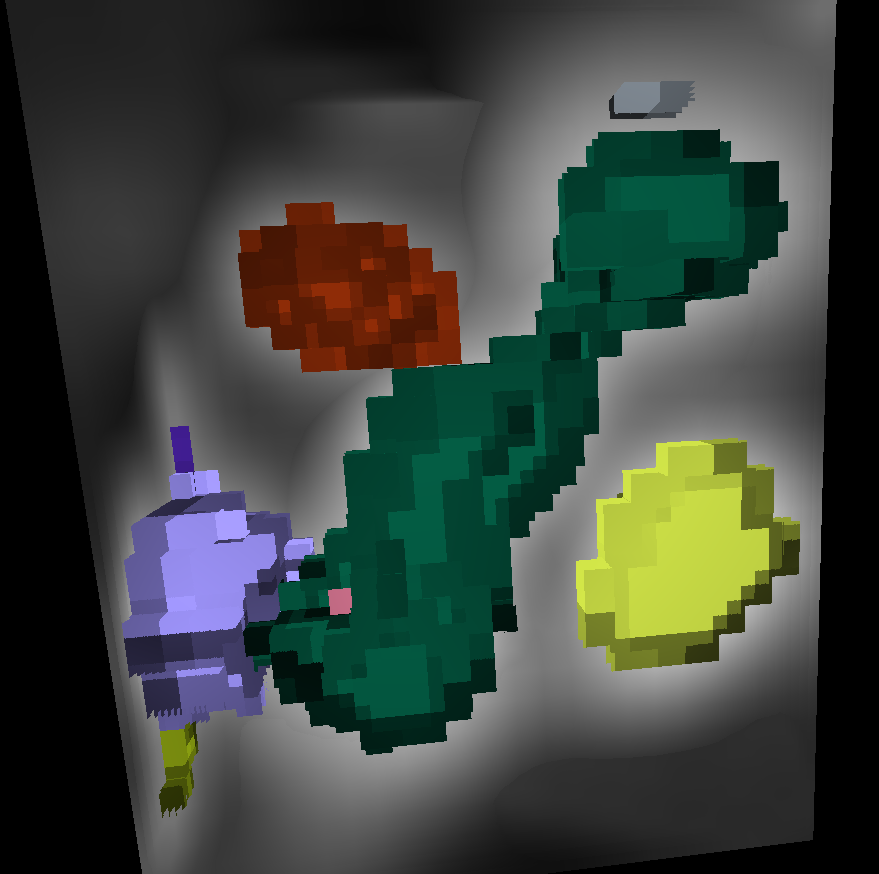

And 220 is here in yellow

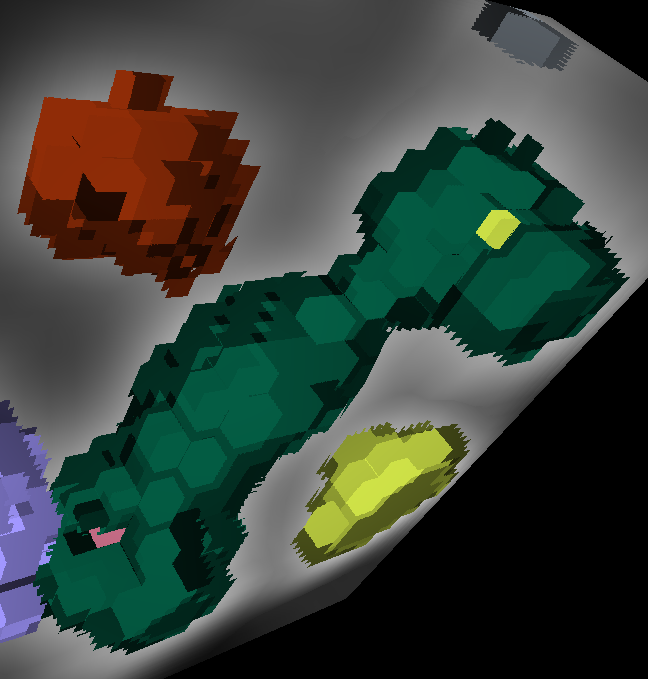

In [52]:
seeds_array.shape

(300, 472, 525)

In [67]:
seeds_array[tuple(seeds_pos[97].T)]

np.int16(97)

In [ ]:
ws[tuple(seeds_pos[97].T)]

Let's test for another annotation too, 292 ws encloses(?) both 546 and 292 seeds

In [18]:
ws[tuple(seeds_pos[546])]

np.int16(0)

In [196]:
pos_tst = seeds_pos[292]

In [200]:
rr = 10
viewer = napari.Viewer()
viewer.add_image(im_for_ws[pos_tst[0]-rr:pos_tst[0]+rr, pos_tst[1]-rr:pos_tst[1]+rr+15, pos_tst[2]-rr:pos_tst[2]+rr])
# viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_image(seeds_array[pos_tst[0]-rr:pos_tst[0]+rr, pos_tst[1]-rr:pos_tst[1]+rr+15, pos_tst[2]-rr:pos_tst[2]+rr])
viewer.add_labels(ws[pos_tst[0]-rr:pos_tst[0]+rr, pos_tst[1]-rr:pos_tst[1]+rr+15, pos_tst[2]-rr:pos_tst[2]+rr])
napari.run()

Same thing turns to be the case for the 292 region: it just has a hole in the pixel position of the other annotation.

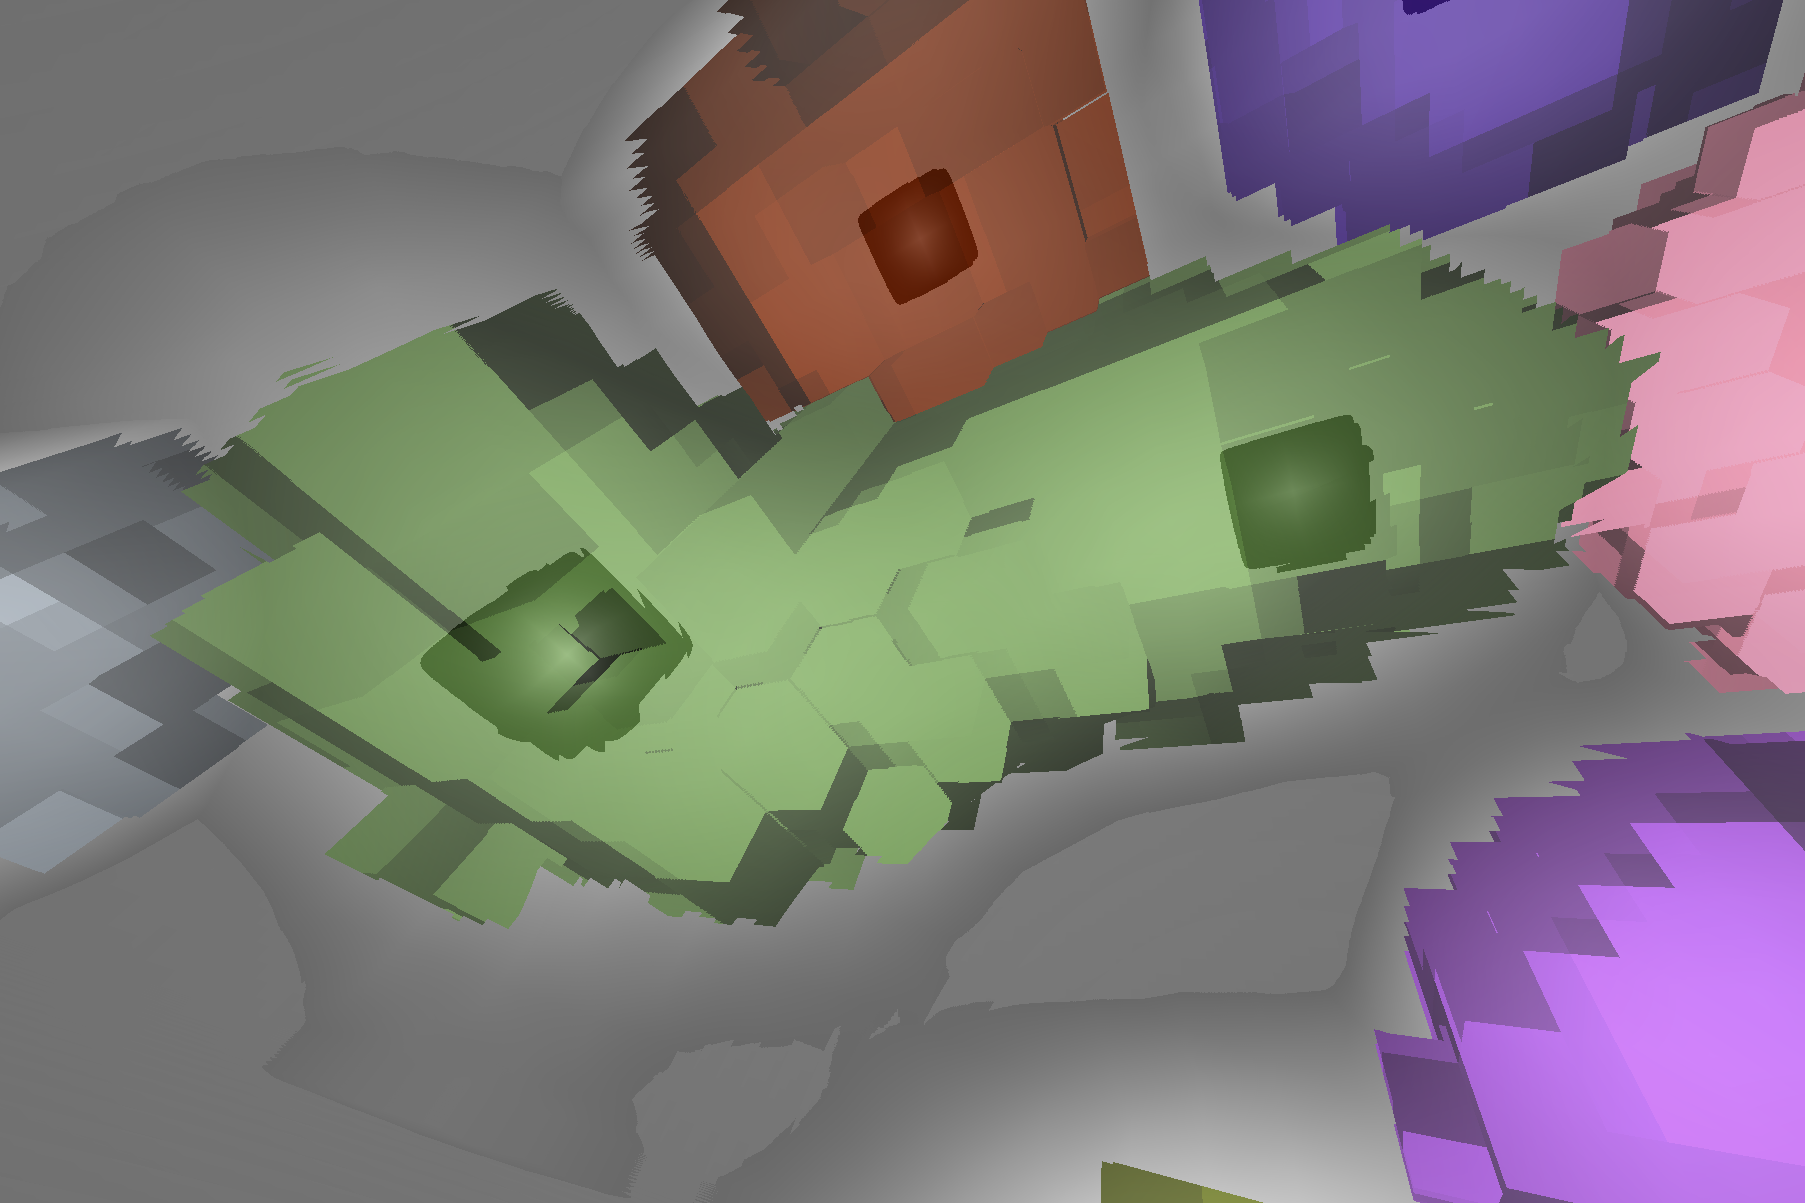

## Identifying multiples cases

In [8]:
pp = seeds_pos[546]
# print(ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2])
li = np.unique(ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2])
mask = li > 0
updated_li = li[mask]
print(updated_li)
print(len(li))

[292]
2


In [ ]:
# FINDING WHAT TO DELETE
missed_multiples = set()
big_multiples = set()

for annotat in all_seeds:
    pp = seeds_pos[annotat]
    image_crop = ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2] # small image around annotation
    labels_in_crop = np.unique(image_crop)
    if ws[tuple(pp)] == 0 and len(labels_in_crop)>1: # 0 is de facto included -> len>=1
        missed_multiples.add(annotat)
        for i in range(1,len(labels_in_crop)): # for the case that it is ajascent to more that one region
            big_multiples.add(labels_in_crop[i])

In [ ]:
import copy

new_ws = copy.deepcopy(ws)

# CLEAR THE WATERSHED FROM GIVEN LABELS
for label in big_multiples:
    new_ws[ws==label] = 0

In [11]:
from skimage.morphology import ball

def add_lost_seeds(ws_in:np.ndarray,
                    seeds_pos,
                    missed_seeds,
                    min_vol=300
):
    """Adds a shperical mask around all missing seeds.
    """

    rad = (3*min_vol/(4*np.pi))**(1/3) # the sphere will have the minimum allowed volume
    rad = int(np.round(rad).astype(np.uint8))
    ball(rad)
    sph_mask = ball(rad) > 0 # make a boolean mask with shperical shape

    for label in missed_seeds:
        pos_ms = seeds_pos[label]
        print(pos_ms)
        padd = ws_in < 0 # this is False everywhere
        padd[pos_ms[0]-rad:pos_ms[0] + rad +1, pos_ms[1]-rad:pos_ms[1]+rad+1, pos_ms[2]-rad:pos_ms[2]+rad+1] = sph_mask
        ws_in[padd] = label

In [12]:
seeds_pos[1]

array([148, 395, 263], dtype=uint16)

In [ ]:
new_ws = main.add_lost_seeds(new_ws, seeds_pos, missed_multiples.union(big_multiples))

In [14]:
len(missed_multiples.union(big_multiples))

67

In [18]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
# viewer.add_image(seeds_array)
viewer.add_labels(new_ws)
viewer.add_labels(ws)

napari.run()

## Region statistics: Bad vs. Good segmentations

To compare statistcs of desirable and bad segmetnations: First identify the bad regions and plot the statistics on the same histogram with good segs using different colors

In [6]:
# FIND MULTIPLES
missed_multiples = set()
big_multiples = set()

for annotat in all_seeds:
    pp = seeds_pos[annotat] # position of the seed
    image_crop = ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2] # small image around annotation
    labels_in_crop = np.unique(image_crop)
    if ws[tuple(pp)] == 0 and len(labels_in_crop)>1: # 0 is de facto included -> len>=1
        missed_multiples.add(annotat)
        for i in range(1,len(labels_in_crop)): # for the case that it is ajascent to more that one region
            big_multiples.add(labels_in_crop[i])

In [7]:
from skimage.measure import regionprops

labels = []
areas = []
sol = []
ext = []
fer_diam = []

for reg in regionprops(ws, raw_image):
    labels.append(reg.label)
    areas.append(reg.area)
    sol.append(reg.solidity)
    ext.append(reg.extent) # pixels area / bbox area
    fer_diam.append(reg.feret_diameter_max)

fer_diam = np.asarray(fer_diam)
areas = np.asarray(areas)

max_vol = 4/3 * 3.1415 * (fer_diam/2)**3

feret_sphere_ratio = areas/max_vol

In [ ]:
weird_regs_ws = np.zeros_like(ws)

for lab in labels[mask]:
    weird_regs_ws[new_ws == lab] = 999

In [ ]:
# REMOVE MULTIPLES FROM WS
import copy

no_multiples = copy.deepcopy(ws)

# CLEAR THE WATERSHED FROM GIVEN LABELS
for label in big_multiples:
    no_multiples[ws==label] = 0

In [ ]:
from skimage.measure import regionprops

labels = []
areas = []
sol = []
ext = []
fer_diam = []

for reg in regionprops(new_ws, raw_image):
    labels.append(reg.label)
    areas.append(reg.area)
    sol.append(reg.solidity)
    ext.append(reg.extent) # pixels area / bbox area
    fer_diam.append(reg.feret_diameter_max)

fer_diam = np.asarray(fer_diam)
areas = np.asarray(areas)

max_vol = 4/3 * 3.1415 * (fer_diam/2)**3

feret_sphere_ratio = areas/max_vol

In [73]:
ws.shape

(300, 472, 525)

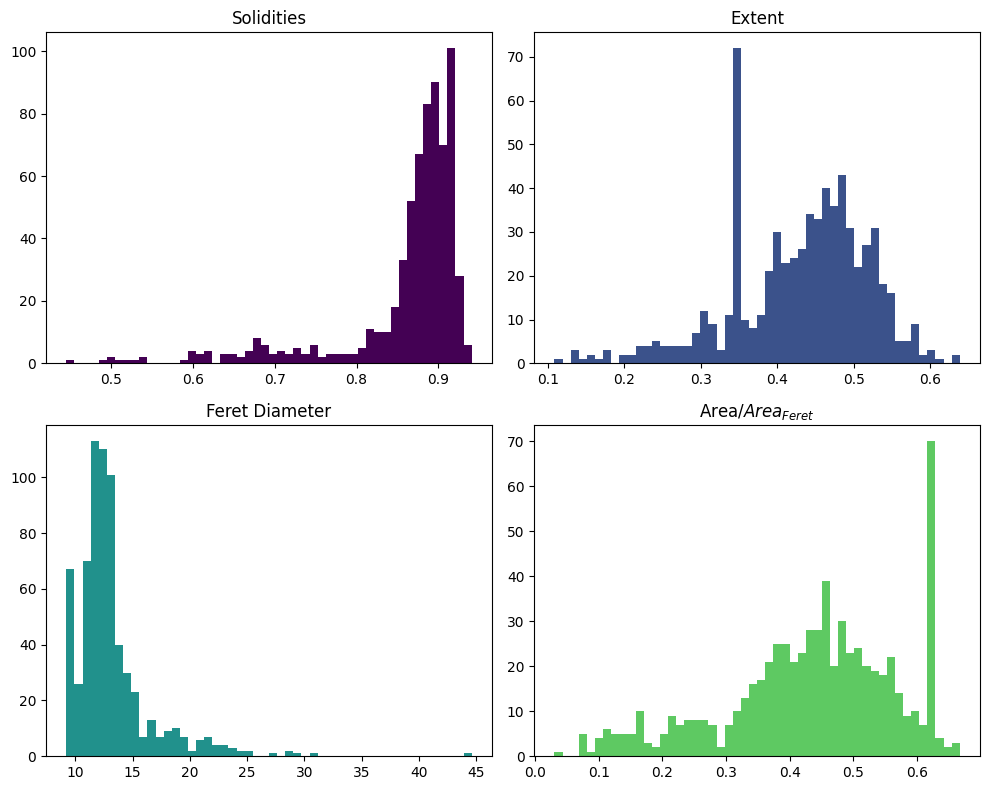

In [17]:
import matplotlib.pyplot as plt

colors = plt.cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(sol, bins=50, color=colors[0])
axes[0,0].set_title('Solidities')

axes[0,1].hist(ext, bins=50, color=colors[1])
axes[0,1].set_title('Extent')

axes[1,0].hist(fer_diam, bins=50, color=colors[2])
axes[1,0].set_title('Feret Diameter')

axes[1,1].hist(feret_sphere_ratio, bins=50, color=colors[3])
axes[1,1].set_title('Area/$Area_{Feret}$')

plt.tight_layout()  # Prevents overlapping labels
plt.show()

In [39]:
labels  = np.asarray(labels, dtype=int)
sol = np.asarray(sol)

In [56]:
mask = sol < 0.65

In [ ]:
weird_regs_ws = np.zeros_like(ws)

for lab in labels[mask]:
    weird_regs_ws[new_ws == lab] = 999

In [72]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
# viewer.add_image(seeds_array)
viewer.add_labels(weird_regs_ws)
viewer.add_labels(new_ws)

napari.run()

Good at identifying the abominations

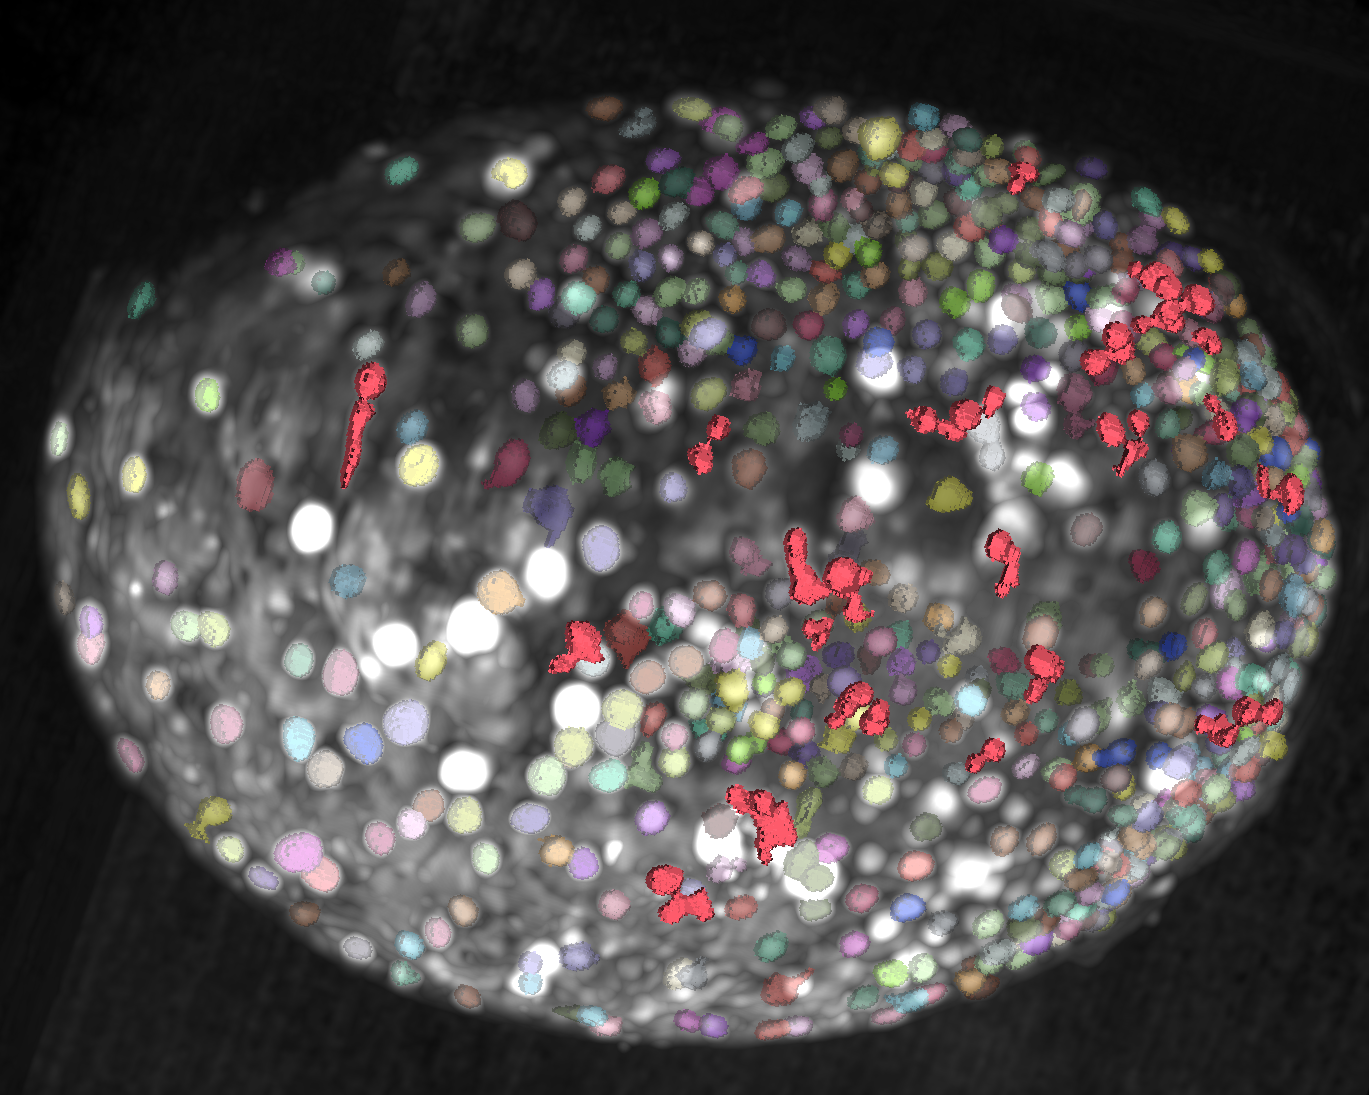

# Use solidities for shape

In [11]:
from enum import Enum

class RegionSet(Enum):
    FINE_REG = "fine"
    MULTIPLE_REG = "multiples"
    WEIRD_REG = "weird"

class RegIon:
    def __init__(self, label, area, solidity, extent, fer_diameter, max_inert):
        self.label = label
        self.area = area
        self.solidity = solidity
        self.extent = extent
        self.fer_diameter = fer_diameter
        self.max_inert = max_inert
        
        max_vol = 4/3 * 3.1415 * (self.fer_diameter/2)**3
        self.feret_sphere_ratio = self.area/max_vol # minimum sphere containig the given region -> probblems with homogenety? 

        corr_radius = 3/(4*3.1415) * (self.area)**(1/3) # corresponding radius of a sphere with area equal to the region area
        self.corr_sphere_rad_ratio = 2*corr_radius/(self.fer_diameter) # two is needed because it's diameter and radius

        

class RegionCollection():
    
    def __init__(self, regions=None):
        self.regions = regions if regions else []
    
    def add(self, region):
        self.regions.append(region)

    def get_attribute(self, attr_name, filter_func=None):
        data = self.regions if not filter_func else filter(filter_func, self.regions)
        return [getattr(m, attr_name) for m in data]
    

In [7]:
# # TEST CLASS BEHAVIOUR
# # Create the set
# regions_list_test = RegionCollection()

# # populate with data
# regions_list_test.add(RegIon(7777, 1,11,111,1111))
# regions_list_test.add(RegIon(7777, 2,22,222,2222))

# cor_sph = regions_list_test.get_attribute("corr_sphere_rad_ratio")
# print(f"all solidities= {cor_sph}")

In [12]:
# FIND MULTIPLES
missed_multiples = set()
big_multiples = set()

for annotat in all_seeds:
    pp = seeds_pos[annotat] # position of the seed
    image_crop = ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2] # small image around annotation
    labels_in_crop = np.unique(image_crop)
    if ws[tuple(pp)] == 0 and len(labels_in_crop)>1: # 0 is de facto included -> len>=1
        missed_multiples.add(annotat)
        for i in range(1,len(labels_in_crop)): # for the case that it is ajascent to more that one region
            big_multiples.add(labels_in_crop[i])

In [13]:
from skimage.measure import regionprops

nice_regs = []
multi_regs = []
weird_regs = []

nice_regs = RegionCollection()
multi_regs = RegionCollection()
weird_regs = RegionCollection()

for reg in regionprops(ws, raw_image):
    if (reg.label in big_multiples):
        multi_regs.add(RegIon(reg.label, reg.area, reg.solidity, reg.extent, reg.feret_diameter_max, reg.inertia_tensor_eigvals[0]))
    elif (reg.label not in big_multiples) and (reg.solidity < 0.65):
        weird_regs.add(RegIon(reg.label, reg.area, reg.solidity, reg.extent, reg.feret_diameter_max, reg.inertia_tensor_eigvals[0]))
    else:
        nice_regs.add(RegIon(reg.label, reg.area, reg.solidity, reg.extent, reg.feret_diameter_max, reg.inertia_tensor_eigvals[0]))

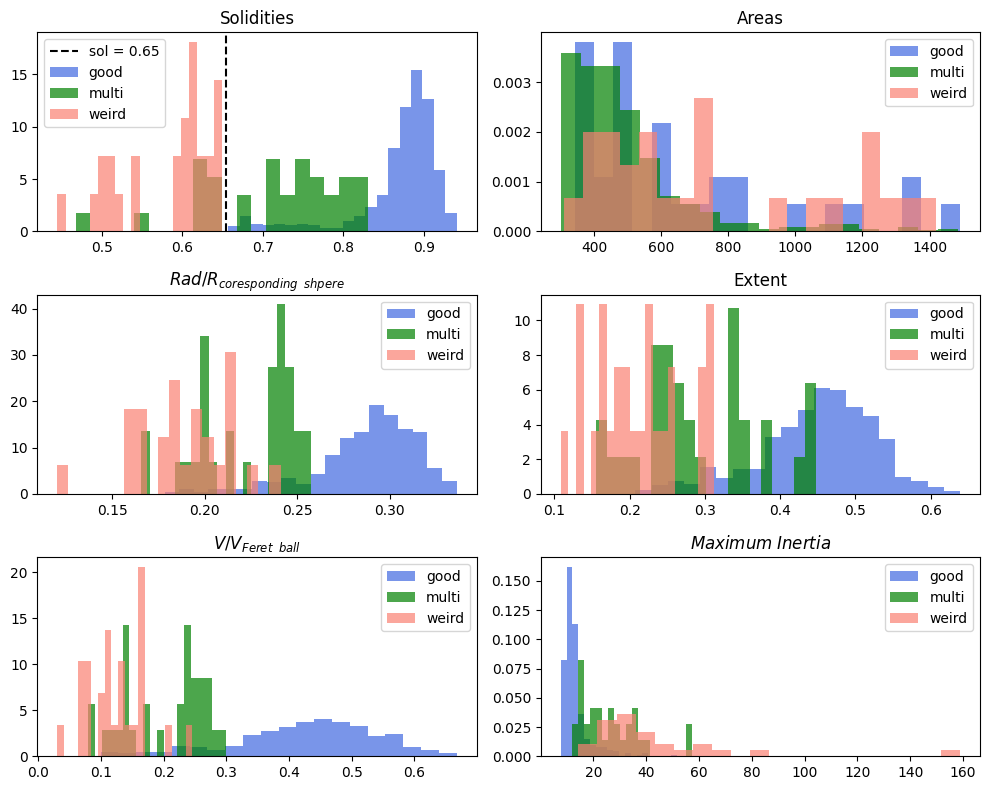

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
good_color = 'royalblue'
multi_color = 'green'
weird_color = 'salmon'

axes[0,0].axvline(x = 0.655, c = 'black', linestyle="--")
axes[0,0].hist(nice_regs.get_attribute("solidity"), color = good_color, density=True, alpha = 0.7, bins=20)
axes[0,0].hist(multi_regs.get_attribute("solidity"), color = multi_color, density=True, alpha = 0.7, bins=20)
axes[0,0].hist(weird_regs.get_attribute("solidity"), color = weird_color, density=True, alpha = 0.7, bins=20)
axes[0,0].legend(['sol = 0.65','good', 'multi', 'weird'])
axes[0,0].set_title('Solidities')

axes[0,1].hist(multi_regs.get_attribute("area"), color = good_color, density=True, alpha = 0.7, bins=20)
axes[0,1].hist(nice_regs.get_attribute("area"), color = multi_color, density=True, alpha = 0.7, bins=20)
axes[0,1].hist(weird_regs.get_attribute("area"), color = weird_color, density=True, alpha = 0.7, bins=20)
axes[0,1].legend(['good', 'multi', 'weird'])
axes[0,1].set_title('Areas')

axes[1,0].hist(nice_regs.get_attribute("corr_sphere_rad_ratio"), color = good_color, density=True, alpha = 0.7, bins=20)
axes[1,0].hist(multi_regs.get_attribute("corr_sphere_rad_ratio"), color = multi_color, density=True, alpha = 0.7, bins=20)
axes[1,0].hist(weird_regs.get_attribute("corr_sphere_rad_ratio"), color = weird_color, density=True, alpha = 0.7, bins=20)
axes[1,0].legend(['good', 'multi', 'weird'])
axes[1,0].set_title('$Rad/R_{coresponding \;\; shpere}$')

axes[1,1].hist(nice_regs.get_attribute("extent"), color = good_color, density=True, alpha = 0.7, bins=20)
axes[1,1].hist(multi_regs.get_attribute("extent"), color = multi_color, density=True, alpha = 0.7, bins=20)
axes[1,1].hist(weird_regs.get_attribute("extent"), color = weird_color, density=True, alpha = 0.7, bins=20)
axes[1,1].legend(['good', 'multi', 'weird'])
axes[1,1].set_title('Extent')

axes[2,0].hist(nice_regs.get_attribute("feret_sphere_ratio"), color = good_color, density=True, alpha = 0.7, bins=20)
axes[2,0].hist(multi_regs.get_attribute("feret_sphere_ratio"), color = multi_color, density=True, alpha = 0.7, bins=20)
axes[2,0].hist(weird_regs.get_attribute("feret_sphere_ratio"), color = weird_color, density=True, alpha = 0.7, bins=20)
axes[2,0].legend(['good', 'multi', 'weird'])
axes[2,0].set_title('$V/V_{Feret \;\; ball}$')

axes[2,1].hist(nice_regs.get_attribute("max_inert"), color = good_color, density=True, alpha = 0.7, bins=20)
axes[2,1].hist(multi_regs.get_attribute("max_inert"), color = multi_color, density=True, alpha = 0.7, bins=20)
axes[2,1].hist(weird_regs.get_attribute("max_inert"), color = weird_color, density=True, alpha = 0.7, bins=20)
axes[2,1].legend(['good', 'multi', 'weird'])
axes[2,1].set_title('$Maximum \; Inertia$')
plt.tight_layout()  # Prevents overlapping labels
plt.show()

The question now becomes, have you clasified them suficiently nicely into the 3 categories?

In [27]:
val_nice = 555
val_multi = 666
val_weird = 777


ws_nice = np.zeros_like(ws)

for lab in nice_regs.get_attribute("label"):
    ws_nice[ws == lab] = val_nice

ws_multi = np.zeros_like(ws)

for lab in multi_regs.get_attribute("label"):
    ws_multi[ws == lab] = val_multi

ws_weird = np.zeros_like(ws)

for lab in weird_regs.get_attribute("label"):
    ws_weird[ws == lab] = val_weird

In [19]:
np.unique(ws_nice)

array([  0, 555], dtype=int16)

In [ ]:
color_dict = {
    0: None,  # background / unmapped labels
    555: "#1e6daeff",  # good
    666: "#07ad31ff",  # multiples
    777: "#e25b3ae1",  # weird
}
from napari.utils.colormaps import DirectLabelColormap
custom_cmap = DirectLabelColormap(color_dict=color_dict)

import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_labels(ws)
viewer.add_labels(ws_nice, colormap=custom_cmap)
viewer.add_labels(ws_multi, colormap=custom_cmap)
viewer.add_labels(ws_weird, colormap=custom_cmap)

napari.run()

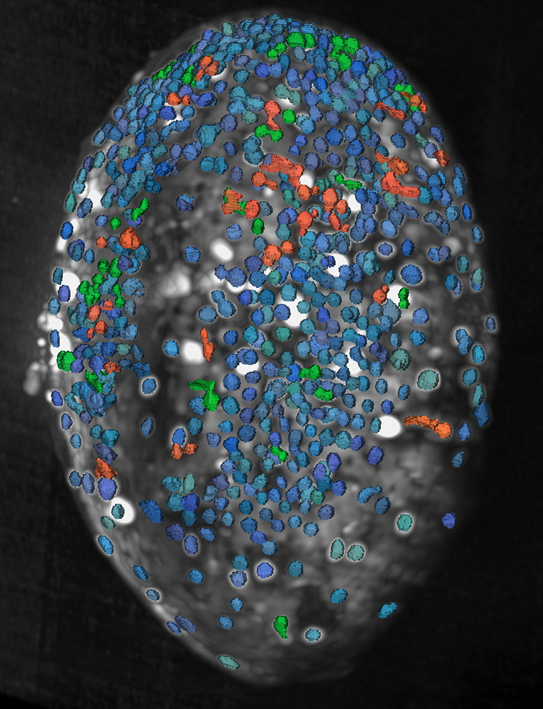

# Use V/V_Feret for shape classification

In [29]:
from enum import Enum

class RegionSet(Enum):
    FINE_REG = "fine"
    MULTIPLE_REG = "multiples"
    WEIRD_REG = "weird"

class RegIon:
    def __init__(self, label, area, fer_diameter):
        self.label = label
        self.area = area
        self.fer_diameter = fer_diameter
        
        max_vol = 4/3 * 3.1415 * (self.fer_diameter/2)**3
        self.feret_sphere_ratio = self.area/max_vol # minimum sphere containig the given region -> probblems with homogenety? 

        corr_radius = 3/(4*3.1415) * (self.area)**(1/3) # corresponding radius of a sphere with area equal to the region area
        self.corr_sphere_rad_ratio = 2*corr_radius/(self.fer_diameter) # two is needed because it's diameter and radius

        

class RegionCollection():
    
    def __init__(self, regions=None):
        self.regions = regions if regions else []
    
    def add(self, region):
        self.regions.append(region)

    def get_attribute(self, attr_name, filter_func=None):
        data = self.regions if not filter_func else filter(filter_func, self.regions)
        return [getattr(m, attr_name) for m in data]

In [30]:
# FIND MULTIPLES
missed_multiples = set()
big_multiples = set()

for annotat in all_seeds:
    pp = seeds_pos[annotat] # position of the seed
    image_crop = ws[pp[0]-1:pp[0]+2,pp[1]-1:pp[1]+2,pp[2]-1:pp[2]+2] # small image around annotation
    labels_in_crop = np.unique(image_crop)
    if ws[tuple(pp)] == 0 and len(labels_in_crop)>1: # 0 is de facto included -> len>=1
        missed_multiples.add(annotat)
        for i in range(1,len(labels_in_crop)): # for the case that it is ajascent to more that one region
            big_multiples.add(labels_in_crop[i])

In [31]:
from skimage.measure import regionprops

# INITIALIZATION
nice_regs = []
multi_regs = []
weird_regs = []

nice_regs = RegionCollection()
multi_regs = RegionCollection()
weird_regs = RegionCollection()

for reg in regionprops(ws, raw_image):
    curr_regi = RegIon(reg.label, reg.area, reg.feret_diameter_max)

    # Classify the region as part of a catogory
    if curr_regi.label in big_multiples:
        multi_regs.add(curr_regi)
    elif curr_regi.feret_sphere_ratio < 0.2:
        weird_regs.add(curr_regi)
    else:
        nice_regs.add(curr_regi)

In [32]:
val_nice = 555
val_multi = 666
val_weird = 777


ws_nice = np.zeros_like(ws)

for lab in nice_regs.get_attribute("label"):
    ws_nice[ws == lab] = val_nice

ws_multi = np.zeros_like(ws)

for lab in multi_regs.get_attribute("label"):
    ws_multi[ws == lab] = val_multi

ws_weird = np.zeros_like(ws)

for lab in weird_regs.get_attribute("label"):
    ws_weird[ws == lab] = val_weird

In [ ]:
color_dict = {
    0: None,  # background / unmapped labels
    555: "#1e6daeff",  # good
    666: "#07ad31ff",  # multiples
    777: "#e25b3ae1",  # weird
}
from napari.utils.colormaps import DirectLabelColormap
custom_cmap = DirectLabelColormap(color_dict=color_dict)

import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_labels(ws)
viewer.add_labels(ws_nice, colormap=custom_cmap)
viewer.add_labels(ws_multi, colormap=custom_cmap)
viewer.add_labels(ws_weird, colormap=custom_cmap)

napari.run()

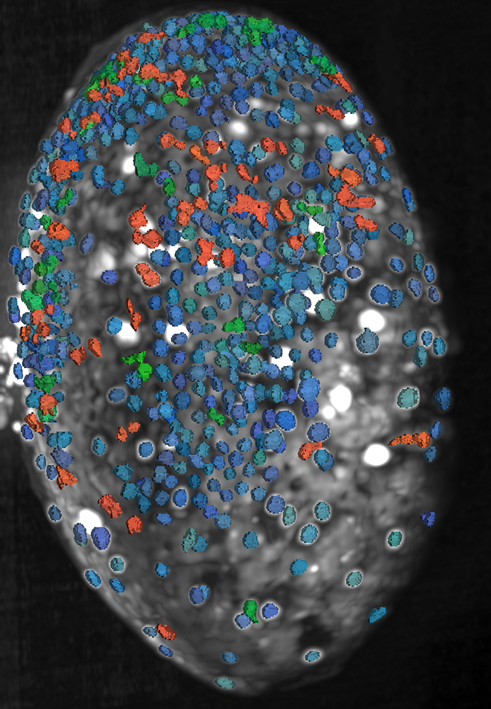

## Shape metric responses

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def ballness(r):
    return (1+r**3)/(1 + r**3 + 3*r**2 + 3*r)

def extent(r):
    return np.pi*(1/6)*(1+r**3)/(1 + r)

def solidity_2d(r):
    
    def zed(r):
        return np.arcsin((1-r)/(1+r))

    return np.pi*(1 + r**2)/(0.5*np.pi*(1 + r**2) + (1/(np.tan(zed(r))) + zed(r))*(1 - r**2))

def zed(r):
    return np.arcsin((1-r)/(1+r))

def x_0(r):
    return np.sin(zed(r))

def x_1(r):
    return 1 + r + r*np.sin(zed(r))

def y_0(r):
    return np.cos(zed(r))

def y_1(r):
    return r*np.cos(zed(r))


In [85]:
np.arcsin(-1)

np.float64(-1.5707963267948966)

In [ ]:
np.seterr(all='raise')
r = np.linspace(0.001,0.999,100)
y_ext = [extent(i) for i in r]
y_ball = [ballness(i) for i in r]

### Do it with Monte Carlo

In [ ]:
def zed(r):
    return np.arcsin((1-r)/(1+r))

def x_0(r):
    return np.sin(zed(r))

def y_0(r):
    return np.cos(zed(r))

def ro(x, r):
    return -np.tan(zed(r))*x + np.tan(zed(r))*x_0(r) + y_0(r)

In [ ]:
R_small = 0.6
NUM_POINTS = 10000

# INITIALIZE VARIABLES
no_in = 0
no_out = 0
in_points = []
out_points = []
region_points = []


for i in range(NUM_POINTS):
    x = -1 + (2+2*R_small)*np.random.random()
    y = -1 + 2*np.random.random()
    z = -1 + 2*np.random.random()

    # FIND POINTS IN CONVEX HULL
    if -1 <= x <= np.sin(zed(R_small)):
        if x**2 + y**2 + z**2 <= 1:
            in_ = True
        else:
            in_ = False

    if np.sin(zed(R_small)) < x < 1 + R_small*(1 + np.sin(zed(R_small))):
        if y**2 + z**2 <= ro(x, R_small)**2:
            in_ = True
        else:
            in_ = False

    if 1 + R_small*(1 + np.sin(zed(R_small))) < x < 1 + 2*R_small:
        if (x - 1 - R_small)**2 + y**2 + z**2 <= R_small**2:
            in_ = True
        else:
            in_ = False

    if in_ == True:
        no_in += 1
        in_points.append([x, y, z])
    if in_ == False:
        no_out += 1
        out_points.append([x, y, z])

    # FIND POINTS IN REGION
    if (x - 1 - R_small)**2 + y**2 + z**2 <= R_small**2:
        in_reg = True
    elif x**2 + y**2 + z**2 <= 1:
        in_reg = True
    else:
        in_reg = False

    if in_reg == True:
        region_points.append([x, y, z])

in_points = np.asarray(in_points)
region_points = np.asarray(region_points)

In [9]:
import plotly.graph_objects as go
import numpy as np

xdata1 = in_points[:,0]
ydata1 = in_points[:,1]
zdata1 = in_points[:,2]

xdata2 = region_points[:,0]
ydata2 = region_points[:,1]
zdata2 = region_points[:,2]



fig = go.Figure(data=[go.Scatter3d(x=xdata1, y=ydata1, z=zdata1,
                                   mode='markers',
                                   name = 'In convex hull',
                                   marker=dict(
                                    size = 3,
                                    color = 'blue',
                                    opacity = 0.5
                                   )),
                        go.Scatter3d(x=xdata2, y=ydata2, z=zdata2,
                                    name = ' In region',
                                    mode='markers', 
                                    marker=dict(
                                    size = 3,
                                    color = 'red',
                                    opacity = 0.1))
                        ])
fig.show()

Do it as a function

In [11]:
def solidiy_monte_carlo(r_small, num_points):

    # INITIALIZE VARIABLES
    no_in_hull = 0
    no_in_reg = 0
    in_points = []
    out_points = []
    region_points = []


    for i in range(num_points):
        x = -1 + (2+2*r_small)*np.random.random()
        y = -1 + 2*np.random.random()
        z = -1 + 2*np.random.random()

        # FIND POINTS IN CONVEX HULL
        if -1 <= x <= np.sin(zed(r_small)):
            if x**2 + y**2 + z**2 <= 1:
                in_ = True
            else:
                in_ = False

        if np.sin(zed(r_small)) < x < 1 + r_small*(1 + np.sin(zed(r_small))):
            if y**2 + z**2 <= ro(x, r_small)**2:
                in_ = True
            else:
                in_ = False

        if 1 + r_small*(1 + np.sin(zed(r_small))) < x < 1 + 2*r_small:
            if (x - 1 - r_small)**2 + y**2 + z**2 <= r_small**2:
                in_ = True
            else:
                in_ = False

        if in_ == True:
            no_in_hull += 1

        # FIND POINTS IN REGION
        if (x - 1 - r_small)**2 + y**2 + z**2 <= r_small**2:
            in_reg = True
        elif x**2 + y**2 + z**2 <= 1:
            in_reg = True
        else:
            in_reg = False

        if in_reg == True:
            no_in_reg += 1

    in_points = np.asarray(in_points)
    region_points = np.asarray(region_points)

    return no_in_reg/no_in_hull

In [19]:
from tqdm import tqdm

r_sol = []
sol_of_r = []

for r_i in tqdm(np.linspace(0, 1, 20, True)):
    r_sol.append(r_i)
    sol_of_r.append(solidiy_monte_carlo(r_i, 100000))

100%|██████████| 20/20 [01:08<00:00,  3.45s/it]


### Visualize

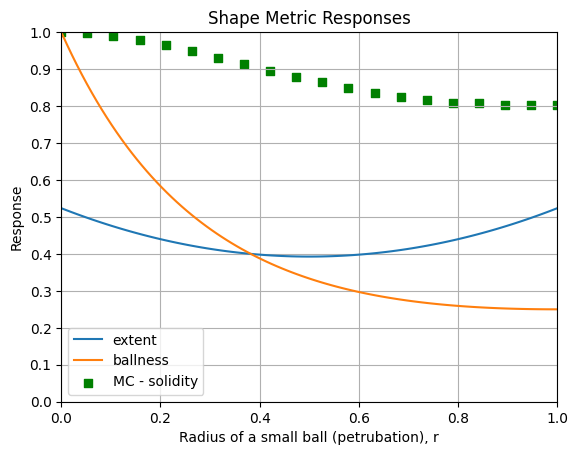

In [158]:
plt.plot(r, y_ext)
plt.plot(r, y_ball)
plt.scatter(r_sol, sol_of_r, marker='s', color = 'green')
# plt.plot(x, y_zed) # ok
plt.legend(['extent', 'ballness', 'MC - solidity'])
plt.ylim([0,1])
plt.xlim([0,1])
plt.yticks([i for i in 0.1*np.asarray(range(0,11,1))])
plt.title('Shape Metric Responses')
plt.xlabel('Radius of a small ball (petrubation), r')
plt.ylabel('Response')
plt.grid()
plt.show()

### Find an analytical solution for solidity

In [159]:
def ballness(r):
    return (1+r**3)/(1 + r**3 + 3*r**2 + 3*r)

def extent(r):
    return np.pi*(1/6)*(1+r**3)/(1 + r)

def zed(r):
    return np.arcsin((1-r)/(1+r))

def solidity_2d(r):
    return np.pi*(1 + r**2)/(0.5*np.pi*(1 + r**2) + (1/(np.tan(zed(r))) + zed(r))*(1 - r**2))

def solidity_3d(r):
    def zed(r):
        return np.arcsin((1-r)/(1+r))

    m = -np.tan(zed(r))
    y_0 = np.cos(zed(r))
    x_0 = np.sin(zed(r))

    # DEFINE THE INTEGRALS NEEDED
    def g_1(x, r):
        return -x**3/3 + r**2*x
             
    def g_2(x):
        a_0 = -m*x_0 + y_0
        return m**2*x**3/3 + 2*m*a_0*x**2/2 + a_0**2*x

    int_1 = np.pi*(g_1(np.sin(zed(r)), 1) - g_1(-1, 1))
    int_2 = np.pi*(g_2(1 + r*(1 + np.sin(zed(r)))) - g_2(x_0))
    int_3 = np.pi*(g_1(r,r) - g_1(r*np.sin(zed(r)), r))
    tot_int = int_1 + int_2 + int_3 

    return 4*np.pi/3*(1 + r**3)/tot_int


In [160]:
r_list = np.linspace(0.001,0.999,100)

y_ext = [extent(i) for i in r_list]
y_ball = [ballness(i) for i in r_list]
y_sol = [solidity_3d(i) for i in r_list]

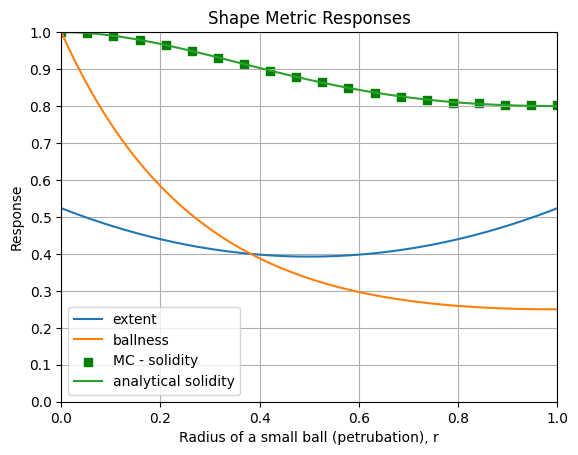

In [ ]:
plt.plot(r_list, y_ext)
plt.plot(r_list, y_ball)
plt.scatter(r_sol, sol_of_r, marker='s', color='green')
plt.plot(r_list, y_sol)
plt.legend(['extent', 'ballness', 'MC - solidity', 'analytical solidity'])
plt.ylim([0,1])
plt.xlim([0,1])
plt.yticks([i for i in 0.1*np.asarray(range(0,11,1))])
plt.title('Shape Metric Responses')
plt.xlabel('Radius of a small ball (petrubation), r')
plt.ylabel('Response')
plt.grid()
plt.show()